linear vs ridge vs lasso
-----------------------------------
linear -> r2: 0.957
ridge -> r2: 0.957
lasso -> r2: 0.956


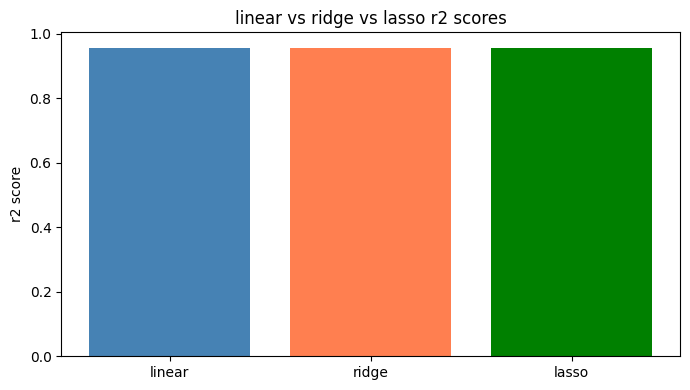

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100

x = pd.DataFrame(np.random.randn(n, 8),
                 columns=["f1","f2","f3","f4","f5","f6","f7","f8"])

y = (x["f1"] * 3 + x["f2"] * 1.5 +
     x["f3"] * 0.5 + np.random.randn(n) * 0.5)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "linear":  LinearRegression(),
    "ridge":   Ridge(alpha=1.0),
    "lasso":   Lasso(alpha=0.1)
}

print("linear vs ridge vs lasso")
print("-" * 35)

scores = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    score = round(r2_score(y_test, model.predict(x_test)), 3)
    scores[name] = score
    print(name, "-> r2:", score)

plt.figure(figsize=(7, 4))
plt.bar(scores.keys(), scores.values(),
        color=["steelblue", "coral", "green"])
plt.title("linear vs ridge vs lasso r2 scores")
plt.ylabel("r2 score")
plt.tight_layout()
plt.show()